# Global Project Analysis

This project analyzes project cost, workforce characteristics, and violation risk to identify key patterns and factors associated with project performance and risk.

## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:

df=pd.read_csv("/content/Global_project.csv")
print(df)




        Project ID  Certificates  Years of Experience  age  \
0           864629             0                    5   45   
1           232937            12                    7   34   
2           987674             0                    4   21   
3           128508             1                    3   52   
4           139393             1                    2   46   
...            ...           ...                  ...  ...   
999995      180796            13                    7   31   
999996      701298            12                    6   40   
999997      994852             0                    3   18   
999998      503775            14                    6   26   
999999      710115            12                    6   29   

        Time Arrival Strafe  Project Cost  Project Proximity  \
0                      5.26      141144.0             111.56   
1                      2.66     1005257.0             131.46   
2                      5.39       51424.0             100.31   

## 2. Data Inspection

Initial inspection of the dataset to understand its structure, dimensions, data types, and basic statistical characteristics.

In [12]:
df.info()
df.shape
df.describe()
df.head()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Project ID             1000000 non-null  int64  
 1   Certificates           1000000 non-null  int64  
 2   Years of Experience    1000000 non-null  int64  
 3   age                    1000000 non-null  int64  
 4   Time Arrival Strafe    1000000 non-null  float64
 5   Project Cost           1000000 non-null  float64
 6   Project Proximity      1000000 non-null  float64
 7   Violation Risk Index   1000000 non-null  float64
 8   Company PCAB Score     1000000 non-null  int64  
 9   Weekly Overtime Hours  1000000 non-null  float64
 10  Salary Bracket         1000000 non-null  int64  
 11  is_good                1000000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 91.6 MB


Index(['Project ID', 'Certificates', 'Years of Experience', 'age',
       'Time Arrival Strafe', 'Project Cost', 'Project Proximity',
       'Violation Risk Index', 'Company PCAB Score', 'Weekly Overtime Hours',
       'Salary Bracket', 'is_good'],
      dtype='object')

## 3. Data Cleaning & Quality Checks

Check the dataset for missing values and duplicate records before proceeding with the analysis.

In [13]:
df.isnull().sum()

,0
Project ID,0
Certificates,0
Years of Experience,0
age,0
Time Arrival Strafe,0
Project Cost,0
Project Proximity,0
Violation Risk Index,0
Company PCAB Score,0
Weekly Overtime Hours,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

,0
Project ID,int64
Certificates,int64
Years of Experience,int64
age,int64
Time Arrival Strafe,float64
Project Cost,float64
Project Proximity,float64
Violation Risk Index,float64
Company PCAB Score,int64
Weekly Overtime Hours,float64


## 4. Exploratory Data Analysis (EDA)

Explore the distribution and relationships of key numerical variables to understand the factors associated with project cost and violation risk.

### 4.1 Project Cost Distribution

Analyze the distribution and summary statistics of project cost to understand its range, central tendency, and frequency pattern.

In [16]:
df["Project Cost"].describe()

,Project Cost
count,1.000000e+06
mean,5.513406e+05
std,4.524546e+05
min,1.000000e+00
25%,9.986675e+04
50%,5.587880e+05
75%,1.000004e+06
max,1.253680e+06


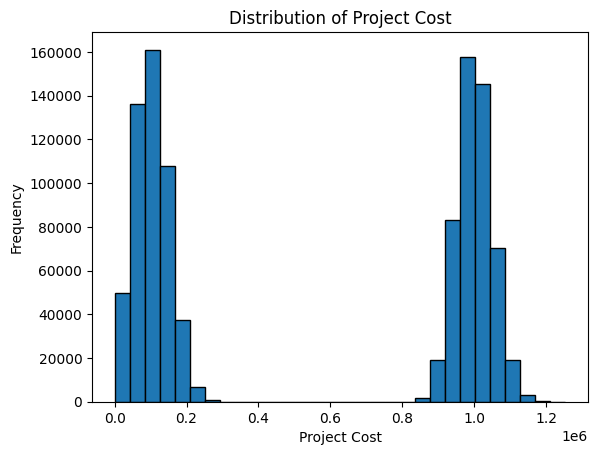

In [17]:
import matplotlib.pyplot as plt
plt.hist(df["Project Cost"], bins=30, edgecolor="black")
plt.xlabel("Project Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Project Cost")
plt.show()


In [18]:
counts, edges = np.histogram(df["Project Cost"], bins=30)

for i in range(len(counts)):
    print(edges[i], "-", edges[i+1], ":", counts[i])

1.0 - 41790.3 : 49909
41790.3 - 83579.6 : 136416
83579.6 - 125368.90000000001 : 161052
125368.90000000001 - 167158.2 : 107789
167158.2 - 208947.5 : 37472
208947.5 - 250736.80000000002 : 6713
250736.80000000002 - 292526.10000000003 : 619
292526.10000000003 - 334315.4 : 30
334315.4 - 376104.7 : 0
376104.7 - 417894.0 : 0
417894.0 - 459683.30000000005 : 0
459683.30000000005 - 501472.60000000003 : 0
501472.60000000003 - 543261.9 : 0
543261.9 - 585051.2000000001 : 0
585051.2000000001 - 626840.5 : 0
626840.5 - 668629.8 : 0
668629.8 - 710419.1000000001 : 0
710419.1000000001 - 752208.4 : 0
752208.4 - 793997.7000000001 : 1
793997.7000000001 - 835787.0 : 40
835787.0 - 877576.3 : 1790
877576.3 - 919365.6000000001 : 19251
919365.6000000001 - 961154.9 : 83243
961154.9 - 1002944.2000000001 : 157576
1002944.2000000001 - 1044733.5000000001 : 145366
1044733.5000000001 - 1086522.8 : 70431
1086522.8 - 1128312.1 : 18939
1128312.1 - 1170101.4000000001 : 3018
1170101.4000000001 - 1211890.7000000002 : 323
121

### 4.2 Correlation with Project Cost

Examine the correlation between Project Cost and other numerical variables to identify the factors most strongly associated with project cost.

In [19]:
df.corr(numeric_only=True)["Project Cost"].sort_values(ascending=False)

,Project Cost
Project Cost,1.000000
Certificates,0.968531
Years of Experience,0.814533
Project Proximity,0.813652
Company PCAB Score,0.809103
Salary Bracket,0.803563
is_good,0.594710
Project ID,-0.000425
Weekly Overtime Hours,-0.094981
age,-0.194744


### 4.3 Certificates Distribution

Examine the frequency distribution of the number of certificates in the dataset.

In [20]:
df["Certificates"].value_counts().sort_index()


,count
Certificates,
0,268673
1,125726
2,64714
3,25686
4,9823
5,3741
6,2180
7,2729
8,6418


### 4.4 Project Cost by Certificates

Analyze how project cost varies across different certificate levels using record count, average, minimum, and maximum project cost.

In [21]:
df.groupby("Certificates")["Project Cost"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Certificates,,,,
0,268673,1.015308e+05,3.0,1010934.0
1,125726,1.012348e+05,1.0,1059143.0
2,64714,1.017380e+05,6.0,1074564.0
3,25686,1.033540e+05,30.0,1115551.0
4,9823,1.129310e+05,81.0,1200810.0
5,3741,1.760609e+05,64.0,1156678.0
6,2180,4.537066e+05,104.0,1183467.0
7,2729,8.342266e+05,1425.0,1169400.0
8,6418,9.715715e+05,15588.0,1184937.0


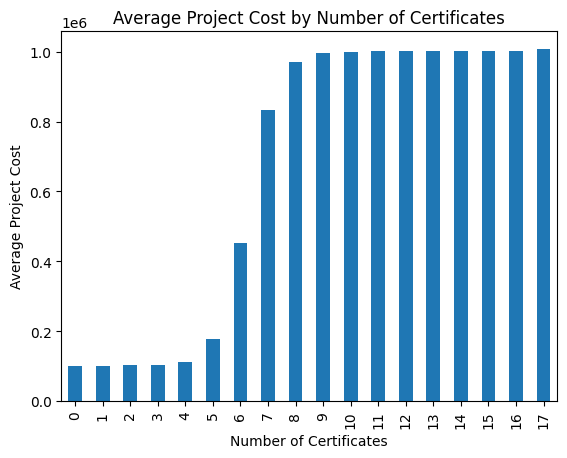

In [22]:
df.groupby("Certificates")["Project Cost"].mean().plot(kind="bar")

plt.xlabel("Number of Certificates")
plt.ylabel("Average Project Cost")
plt.title("Average Project Cost by Number of Certificates")

plt.show()

### 4.5 Violation Risk Analysis

Analyze the Violation Risk Index to understand its distribution and identify the factors associated with higher or lower project risk.

In [23]:
df["Violation Risk Index"].describe()

,Violation Risk Index
count,1000000.000000
mean,0.431012
std,0.191105
min,0.080000
25%,0.250000
50%,0.400000
75%,0.600000
max,0.900000


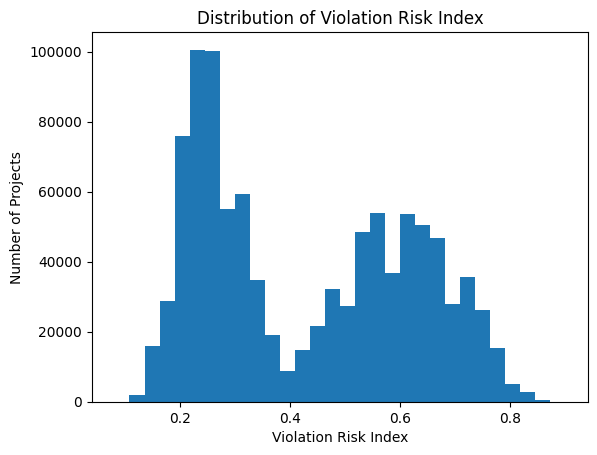

In [24]:
plt.hist(df["Violation Risk Index"], bins=30)

plt.xlabel("Violation Risk Index")
plt.ylabel("Number of Projects")
plt.title("Distribution of Violation Risk Index")

plt.show()

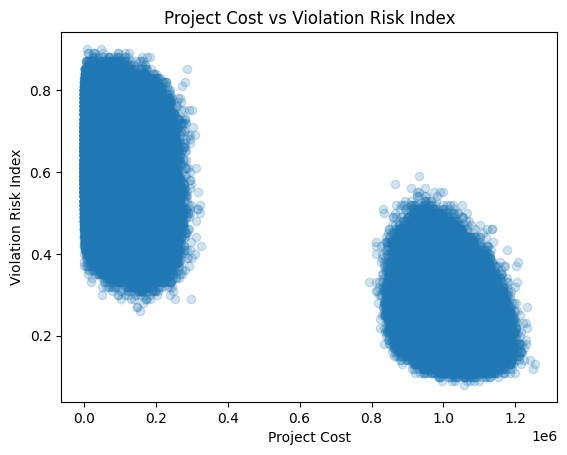

In [25]:
plt.scatter(df["Project Cost"], df["Violation Risk Index"], alpha=0.2)

plt.xlabel("Project Cost")
plt.ylabel("Violation Risk Index")
plt.title("Project Cost vs Violation Risk Index")

plt.show()

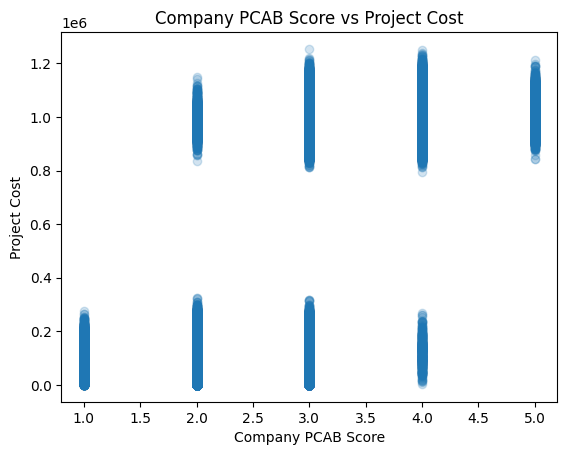

In [26]:
plt.scatter(df["Company PCAB Score"], df["Project Cost"], alpha=0.2)

plt.xlabel("Company PCAB Score")
plt.ylabel("Project Cost")
plt.title("Company PCAB Score vs Project Cost")

plt.show()

In [27]:
df.groupby("Company PCAB Score")["Project Cost"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Company PCAB Score,,,,
1,14977,9.053086e+04,1.0,275517.0
2,352038,1.028853e+05,3.0,1147207.0
3,324791,6.298179e+05,6.0,1253680.0
4,301171,1.002995e+06,5006.0,1249733.0
5,7023,1.015676e+06,844216.0,1212406.0


### 4.6 Experience and Project Cost Analysis

Analyze how years of experience are associated with project cost and identify patterns across different experience levels.

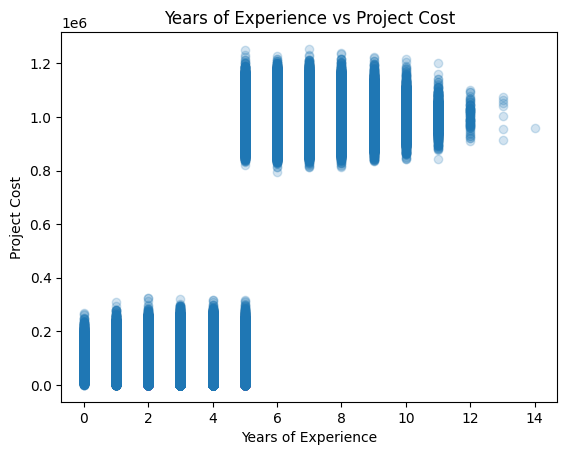

In [28]:
plt.scatter(
    df["Years of Experience"],
    df["Project Cost"],
    alpha=0.2
)

plt.xlabel("Years of Experience")
plt.ylabel("Project Cost")
plt.title("Years of Experience vs Project Cost")

plt.show()

In [29]:
df.groupby("Years of Experience")["Project Cost"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Years of Experience,,,,
0,4009,1.022305e+05,63.0,268588.0
1,25588,1.015509e+05,1.0,311046.0
2,74685,1.012592e+05,8.0,324523.0
3,142048,1.015631e+05,3.0,321658.0
4,175271,1.014094e+05,14.0,318568.0
5,156403,5.501830e+05,9.0,1249733.0
6,175224,1.001169e+06,793053.0,1229004.0
7,140616,1.001260e+06,813089.0,1253680.0
8,74244,1.001261e+06,813276.0,1239902.0


### 4.7 Violation Risk Correlation Analysis

Identify the numerical variables most strongly associated with the Violation Risk Index.

In [30]:
df.corr(numeric_only=True)["Violation Risk Index"].sort_values(ascending=False)

,Violation Risk Index
Violation Risk Index,1.000000
Time Arrival Strafe,0.513112
age,0.437742
Weekly Overtime Hours,0.398243
Project ID,0.000482
is_good,-0.543930
Project Proximity,-0.570078
Salary Bracket,-0.732698
Company PCAB Score,-0.738681
Years of Experience,-0.744793


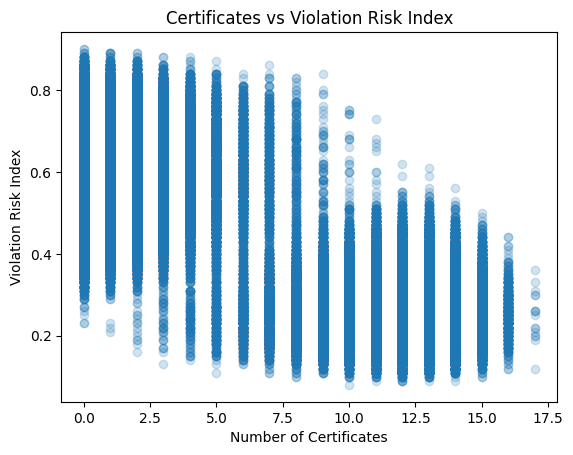

In [31]:
plt.scatter(
    df["Certificates"],
    df["Violation Risk Index"],
    alpha=0.2
)

plt.xlabel("Number of Certificates")
plt.ylabel("Violation Risk Index")
plt.title("Certificates vs Violation Risk Index")

plt.show()

In [32]:
df.groupby("Certificates")["Violation Risk Index"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Certificates,,,,
0,268673,0.604511,0.23,0.90
1,125726,0.605367,0.21,0.89
2,64714,0.604493,0.16,0.89
3,25686,0.603881,0.13,0.88
4,9823,0.601144,0.14,0.88
5,3741,0.574980,0.11,0.87
6,2180,0.469743,0.13,0.84
7,2729,0.322364,0.11,0.86
8,6418,0.268730,0.10,0.83


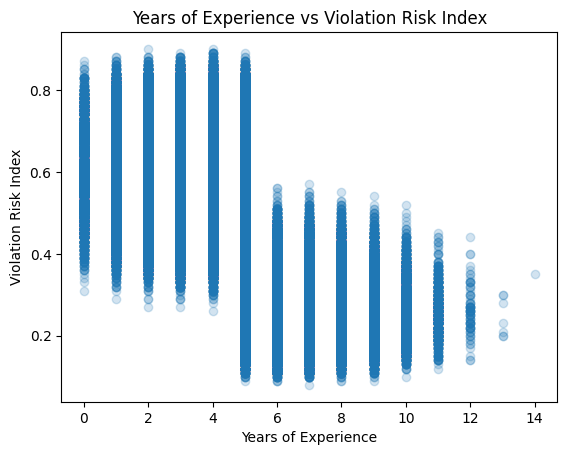

In [33]:
plt.scatter(
    df["Years of Experience"],
    df["Violation Risk Index"],
    alpha=0.2
)

plt.xlabel("Years of Experience")
plt.ylabel("Violation Risk Index")
plt.title("Years of Experience vs Violation Risk Index")

plt.show()

In [34]:
df.groupby("Years of Experience")["Violation Risk Index"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Years of Experience,,,,
0,4009,0.603926,0.31,0.87
1,25588,0.604737,0.29,0.88
2,74685,0.604755,0.27,0.90
3,142048,0.604607,0.27,0.89
4,175271,0.605139,0.26,0.90
5,156403,0.431275,0.09,0.89
6,175224,0.257100,0.09,0.56
7,140616,0.257477,0.08,0.57
8,74244,0.257115,0.09,0.55


In [35]:
df.groupby("Company PCAB Score")["Violation Risk Index"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Company PCAB Score,,,,
1,14977,0.608580,0.32,0.89
2,352038,0.604012,0.13,0.90
3,324791,0.400654,0.08,0.89
4,301171,0.256834,0.09,0.84
5,7023,0.253765,0.11,0.48


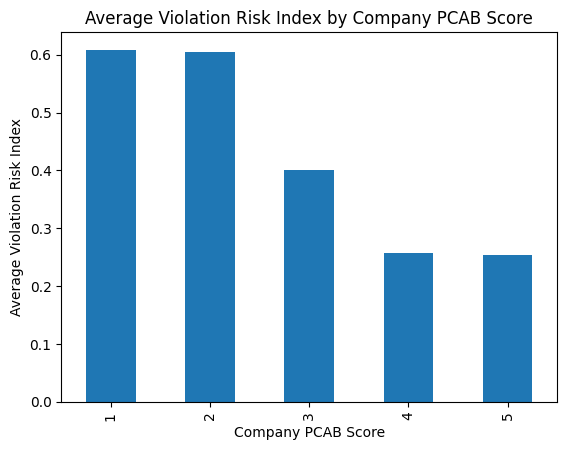

In [36]:
df.groupby("Company PCAB Score")["Violation Risk Index"].mean().plot(
    kind="bar"
)

plt.xlabel("Company PCAB Score")
plt.ylabel("Average Violation Risk Index")
plt.title("Average Violation Risk Index by Company PCAB Score")

plt.show()

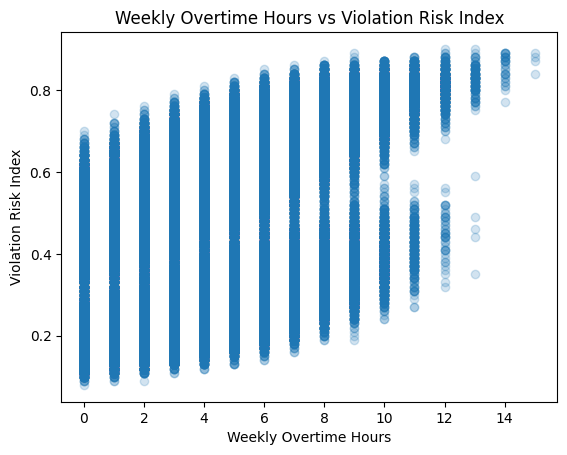

In [37]:
plt.scatter(
    df["Weekly Overtime Hours"],
    df["Violation Risk Index"],
    alpha=0.2
)

plt.xlabel("Weekly Overtime Hours")
plt.ylabel("Violation Risk Index")
plt.title("Weekly Overtime Hours vs Violation Risk Index")

plt.show()

In [38]:
df.groupby("Weekly Overtime Hours")["Violation Risk Index"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Weekly Overtime Hours,,,,
0.0,53405,0.339368,0.08,0.70
1.0,72610,0.347474,0.09,0.74
2.0,120439,0.363331,0.09,0.76
3.0,161258,0.382673,0.11,0.79
4.0,175386,0.408830,0.12,0.81
5.0,157723,0.443131,0.13,0.83
6.0,117218,0.488497,0.14,0.85
7.0,73755,0.541511,0.16,0.86
8.0,39634,0.602523,0.19,0.87


## 5. Key Performance Indicators (KPIs)

Calculate the key project and workforce metrics used to summarize overall project performance and risk.

In [39]:
total_projects = df["Project ID"].nunique()

print("Total Projects:", total_projects)

Total Projects: 1000000


In [40]:
avg_project_cost = df["Project Cost"].mean()

print("Average Project Cost:", avg_project_cost)

Average Project Cost: 551340.64803


In [41]:
avg_risk = df["Violation Risk Index"].mean()

print("Average Violation Risk Index:", avg_risk)

Average Violation Risk Index: 0.43101191000000033


In [42]:
avg_overtime = df["Weekly Overtime Hours"].mean()

print("Average Weekly Overtime Hours:", avg_overtime)

Average Weekly Overtime Hours: 4.095588


In [43]:
avg_pcab = df["Company PCAB Score"].mean()

print("Average Company PCAB Score:", avg_pcab)

Average Company PCAB Score: 2.933225


In [44]:
avg_experience = df["Years of Experience"].mean()

print("Average Years of Experience:", avg_experience)

Average Years of Experience: 5.008628




 ## 6. Key Insights

- Project Cost showed strong positive associations with the number of Certificates, Years of Experience, and Company PCAB Score.

- Higher certification levels were generally associated with higher Project Cost, with a noticeable increase after the mid-certificate range.

- Greater Years of Experience were associated with higher Project Cost, with a clear increase around the mid-experience levels.

- Higher Company PCAB Scores were associated with higher Project Cost.

- Violation Risk Index showed a strong negative association with Project Cost, indicating that higher-cost projects in this dataset were generally associated with lower violation risk.

- Higher numbers of Certificates and greater Years of Experience were generally associated with lower Violation Risk.

- Higher Company PCAB Scores were also associated with lower Violation Risk, with risk decreasing substantially at higher score levels.

- Weekly Overtime Hours showed a positive association with Violation Risk, although the relationship was weaker than the major project and workforce factors.

- Overall, the analysis indicates that experience, certifications, and company performance indicators are important factors associated with project value and violation risk.